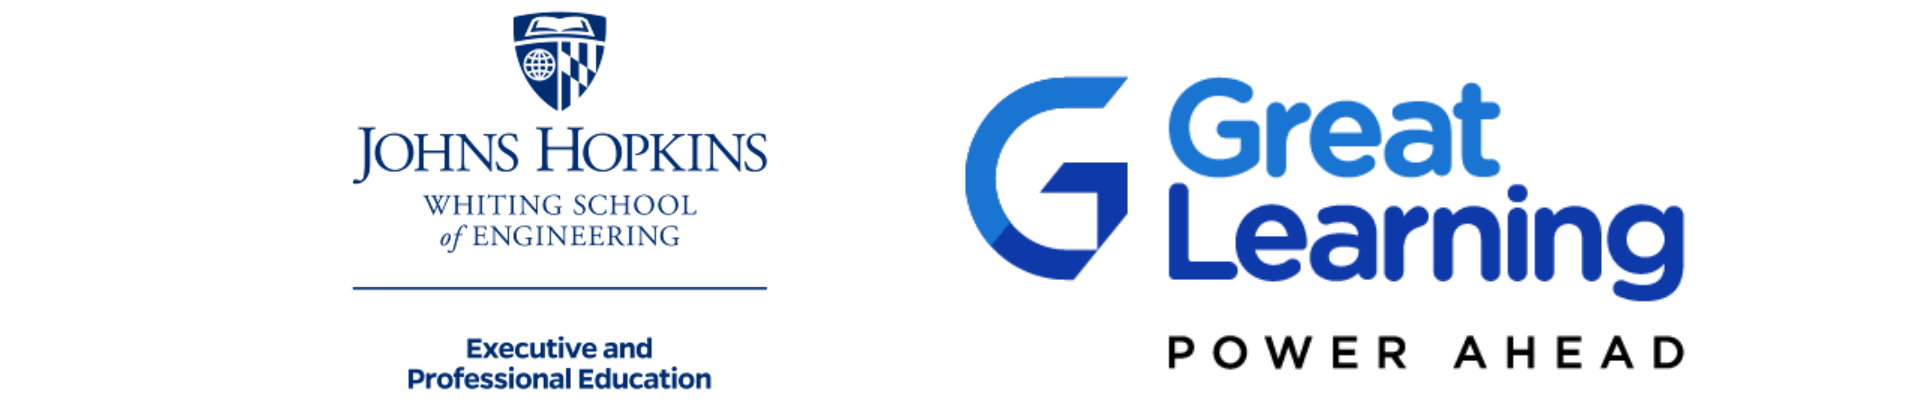

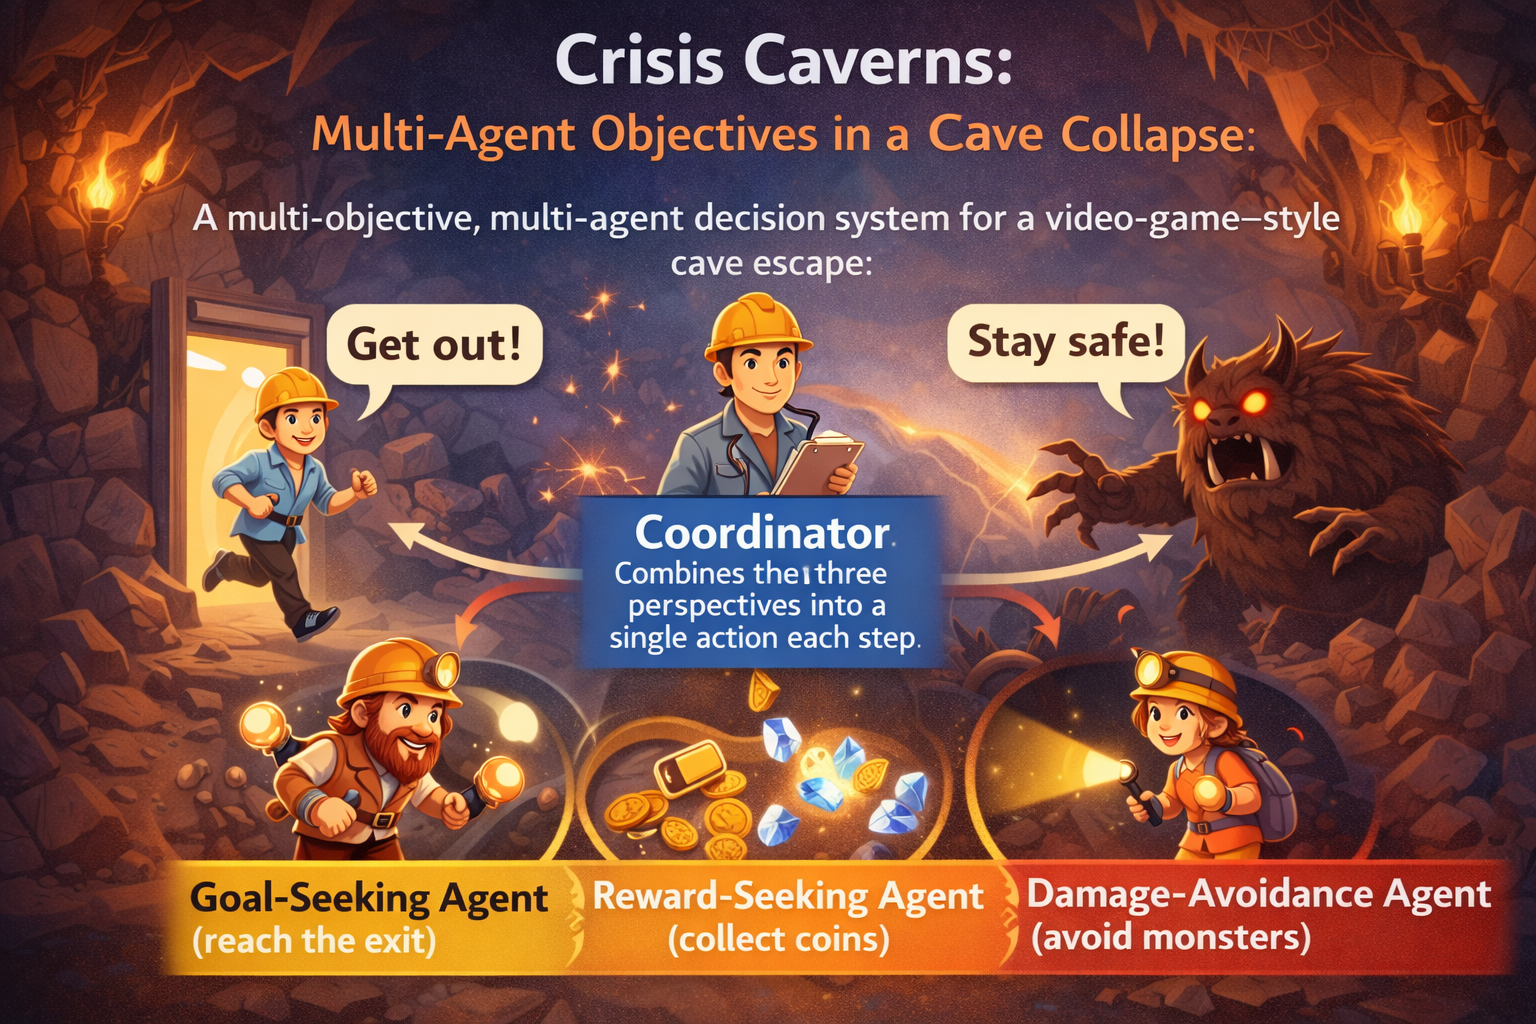

# Agentic AI Reinforcement Learning Lab  
## *Crisis Caverns: Multi-Agent Objectives in a Cave Collapse*

---

### What you’ll build
A **multi-objective, multi-agent** decision system for a video-game–style cave escape:

- **Goal-Seeking Agent**: “Get out!” (reach the exit)
- **Reward-Seeking Agent**: “Grab crystals!” (collect coins)
- **Damage-Avoidance Agent**: “Stay safe!” (avoid monsters)
- **Coordinator**: combines the three perspectives into a single action each step

This notebook is built for **independent learners**:
- Exposition + runnable code
- Checkpoints/reflection per section
- “Dashboard-like” plots to evaluate behavior
- Simulation is **clearly labeled**; optional **online API** calls are **opt-in**

> Tip: run cells top-to-bottom. If you get stuck, re-run the environment setup cells.

---

## 0. Game Scenario: Cave Collapse While Exploring

You are an explorer trapped underground after a **cave collapse** during a scientific expedition.

Inside the caverns:
- An **exit shaft** leads back to the surface
- **Energy crystals (coins)** can be collected to power emergency equipment
- **Hostile cave creatures (monsters)** roam the tunnels and cause injury

You control an **agentic AI explorer** that must learn through **interaction**.

### Competing objectives
| Objective | Meaning |
|---|---|
| Goal-Seeking | Escape the cave (reach exit) |
| Reward-Seeking | Collect crystals |
| Damage Avoidance | Minimize monster encounters |

No single strategy perfectly optimizes all three.

### 🔎 Checkpoint 0
If *you* were trapped, what would you prioritize first (escape / crystals / safety)? Why?

## 1. RL Refresher + Multi-Objective Framing

### Reinforcement Learning (RL)
At each step:
1. Agent observes a **state**
2. Agent picks an **action**
3. Environment returns: new state, reward, and done flag

### Multi-objective RL
Here we treat reward as a **vector** (one component per objective), then decide via a **coordinator**.

We’ll measure performance in a structured way:
- **Escape success**
- **Coins collected**
- **Monster hits**
- **Steps / time**
- **Scalar return** (a weighted combination)

### 🔎 Checkpoint 1
Why might a *single* scalar reward hide important tradeoffs in this scenario?

In [ ]:
# ============================
# 2. Imports & Configuration
# ============================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from collections import defaultdict, deque

# Reproducibility
random.seed(42)
np.random.seed(42)

# Gridworld parameters (bigger => more variation)
GRID_SIZE = 10
MAX_STEPS = 120

# More coins/monsters to see richer behavior variation
NUM_COINS_RANGE = (18, 28)
NUM_MONSTERS_RANGE = (10, 14)

ACTIONS = ["UP", "DOWN", "LEFT", "RIGHT"]
ACTION_TO_DELTA = {"UP":(-1,0), "DOWN":(1,0), "LEFT":(0,-1), "RIGHT":(0,1)}

# Vector reward components
R_EXIT = 1.0          # success signal
R_COIN = 1.0          # coin collection signal
R_DAMAGE = -1.0       # monster hit signal (negative)
R_STEP = -0.01        # time pressure

# Coordinator weights (baseline)
DEFAULT_WEIGHTS = {
    "goal": 3.0,
    "coins": 1.0,
    "safety": 2.0,
    "time": 0.5,
}

print("Configured GRID_SIZE =", GRID_SIZE)

Configured GRID_SIZE = 10


### 🔎 Checkpoint 2 — Reward Design
How do the *weights* (goal/coins/safety/time) encode values or priorities?  
Who should be responsible for choosing them in a real deployment?

In [ ]:
# ============================
# 3. Environment: Crisis Caverns (SIMULATION)
# ============================
# This is a simulated environment for learning. In real systems, the environment
# might be a digital twin, a game engine, or real-world logs + replay.

@dataclass
class StepInfo:
    got_coin: bool = False
    hit_monster: bool = False
    reached_exit: bool = False

class CrisisCavernsEnv:
    def __init__(self, grid_size=GRID_SIZE):
        self.grid_size = grid_size
        self.reset()

    def reset(self):
        self.agent = (0, 0)
        self.exit = (self.grid_size - 1, self.grid_size - 1)

        all_cells = [(i, j) for i in range(self.grid_size) for j in range(self.grid_size)]
        available = [c for c in all_cells if c not in [self.agent, self.exit]]

        self.coins = set(random.sample(available, random.randint(*NUM_COINS_RANGE)))
        available2 = [c for c in available if c not in self.coins]
        self.monsters = set(random.sample(available2, random.randint(*NUM_MONSTERS_RANGE)))

        self.steps = 0
        self.coins_collected = 0
        self.monster_hits = 0
        return self._obs()

    def _obs(self):
        # Compact observation: agent (x,y), exit (x,y), plus local hazard/coin indicators
        ax, ay = self.agent
        ex, ey = self.exit
        # Local view: 4-neighborhood booleans
        neigh = {}
        for a, (dx, dy) in ACTION_TO_DELTA.items():
            nx, ny = ax+dx, ay+dy
            if 0 <= nx < self.grid_size and 0 <= ny < self.grid_size:
                neigh[f"coin_{a}"] = int((nx, ny) in self.coins)
                neigh[f"monster_{a}"] = int((nx, ny) in self.monsters)
            else:
                neigh[f"coin_{a}"] = 0
                neigh[f"monster_{a}"] = 0
        return (ax, ay, ex, ey, neigh)

    def step(self, action):
        ax, ay, ex, ey, neigh = self._obs()
        dx, dy = ACTION_TO_DELTA[action]
        nx, ny = max(0, min(self.grid_size-1, ax+dx)), max(0, min(self.grid_size-1, ay+dy))
        self.agent = (nx, ny)
        self.steps += 1

        info = StepInfo()
        # Vector reward components: (goal, coins, safety, time)
        r_goal = 0.0
        r_coin = 0.0
        r_safety = 0.0
        r_time = R_STEP

        if self.agent in self.coins:
            self.coins.remove(self.agent)
            self.coins_collected += 1
            r_coin += R_COIN
            info.got_coin = True

        if self.agent in self.monsters:
            self.monster_hits += 1
            r_safety += R_DAMAGE
            info.hit_monster = True

        done = False
        if self.agent == self.exit:
            r_goal += R_EXIT
            info.reached_exit = True
            done = True

        if self.steps >= MAX_STEPS:
            done = True

        obs = self._obs()
        vec_reward = {"goal": r_goal, "coins": r_coin, "safety": r_safety, "time": r_time}
        return obs, vec_reward, done, info

def render_ascii(env: CrisisCavernsEnv, view_size=10):
    # Simple text render for understanding (not optimized for performance).
    gs = env.grid_size
    grid = [["." for _ in range(gs)] for _ in range(gs)]
    for (x,y) in env.coins:
        grid[x][y] = "C"
    for (x,y) in env.monsters:
        grid[x][y] = "M"
    ax, ay = env.agent
    ex, ey = env.exit
    grid[ex][ey] = "E"
    grid[ax][ay] = "A"
    print("\n".join(" ".join(row) for row in grid))

env = CrisisCavernsEnv()
_ = env.reset()
render_ascii(env)

A . . . . . C M . .
. C . M . M C . . .
. . . . . C . . . .
. . . . C M . . C .
. . M . M C C C . C
. . . . . . . M . C
M . . . . . . . . C
. C M . C . . . C .
C C . . . . . . . .
. C . . C . . M . E


### 🔎 Checkpoint 3 — Observability
What information is the agent missing here (relative to a human player)?  
How might that change what “good performance” looks like?

## 4. Multi-Agent Decision Making

We explicitly model **three sub-agents** that each propose an action:
- **GoalSeeker**: moves toward the exit
- **CoinSeeker**: moves toward the nearest visible coin (or explores)
- **DamageAvoider**: avoids moves likely to hit monsters

Then a **Coordinator** combines their preferences.

This pattern is common in agentic systems:
- specialist modules propose options
- a controller arbitrates tradeoffs

In [ ]:
# ============================
# 4.1 Helper functions
# ============================

def manhattan(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def valid_move(pos, action, grid_size):
    x, y = pos
    dx, dy = ACTION_TO_DELTA[action]
    nx, ny = x+dx, y+dy
    return 0 <= nx < grid_size and 0 <= ny < grid_size

def next_pos(pos, action, grid_size):
    x, y = pos
    dx, dy = ACTION_TO_DELTA[action]
    nx, ny = max(0, min(grid_size-1, x+dx)), max(0, min(grid_size-1, y+dy))
    return (nx, ny)

In [ ]:
# ============================
# 4.2 Sub-agents: propose action + score
# ============================

class GoalSeeker:
    name = "goal"
    def score_action(self, env: CrisisCavernsEnv, action):
        ax, ay = env.agent
        ex, ey = env.exit
        cur = manhattan((ax,ay),(ex,ey))
        nxt = manhattan(next_pos((ax,ay), action, env.grid_size), (ex,ey))
        # Prefer actions that reduce distance to exit
        return float(cur - nxt)

class CoinSeeker:
    name = "coins"
    def score_action(self, env: CrisisCavernsEnv, action):
        ax, ay = env.agent
        if not env.coins:
            return 0.0
        nxt = next_pos((ax,ay), action, env.grid_size)
        # Prefer actions that move toward nearest coin
        nearest = min(env.coins, key=lambda c: manhattan(nxt, c))
        cur_nearest = min(env.coins, key=lambda c: manhattan((ax,ay), c))
        cur_d = manhattan((ax,ay), cur_nearest)
        nxt_d = manhattan(nxt, nearest)
        return float(cur_d - nxt_d)

class DamageAvoider:
    name = "safety"
    def score_action(self, env: CrisisCavernsEnv, action):
        ax, ay = env.agent
        nxt = next_pos((ax,ay), action, env.grid_size)
        # Big penalty if stepping onto monster, smaller if stepping adjacent to monsters
        if nxt in env.monsters:
            return -5.0
        # Penalize adjacency (risk)
        risk = 0
        for a2 in ACTIONS:
            n2 = next_pos(nxt, a2, env.grid_size)
            if n2 in env.monsters:
                risk += 1
        return -0.5 * risk

In [ ]:
# ============================
# 4.3 Coordinator: combine proposals
# ============================

class Coordinator:
    def __init__(self, weights=None, temperature=0.0):
        self.weights = dict(DEFAULT_WEIGHTS if weights is None else weights)
        self.temperature = float(temperature)  # 0 => greedy; >0 => softmax

        self.goal = GoalSeeker()
        self.coins = CoinSeeker()
        self.safety = DamageAvoider()
        self.subagents = [self.goal, self.coins, self.safety]

    def choose_action(self, env: CrisisCavernsEnv):
        ax = env.agent
        scores = {}
        for a in ACTIONS:
            # Combine specialist scores with weights
            s_goal = self.goal.score_action(env, a)
            s_coin = self.coins.score_action(env, a)
            s_safe = self.safety.score_action(env, a)
            # Add time pressure: discourage no-op-ish moves by small penalty if move doesn't change position
            nxt = next_pos(ax, a, env.grid_size)
            time_pen = -1.0 if nxt == ax else 0.0

            total = (
                self.weights["goal"] * s_goal +
                self.weights["coins"] * s_coin +
                self.weights["safety"] * s_safe +
                self.weights["time"] * time_pen
            )
            scores[a] = total

        # Choose action
        if self.temperature <= 0:
            best = max(scores.items(), key=lambda kv: kv[1])[0]
            return best, scores
        else:
            # Softmax exploration
            vals = np.array([scores[a] for a in ACTIONS], dtype=float)
            vals = vals - vals.max()
            probs = np.exp(vals / self.temperature)
            probs = probs / probs.sum()
            choice = np.random.choice(ACTIONS, p=probs)
            return choice, scores

coord = Coordinator(temperature=0.15)
print("Coordinator weights:", coord.weights)

Coordinator weights: {'goal': 3.0, 'coins': 1.0, 'safety': 2.0, 'time': 0.5}


### 🔎 Checkpoint 4 — Multi-Agent Behavior
In this design, sub-agents do **not** execute actions directly—they only *advise*.

What are the benefits and risks of this architecture versus a single monolithic RL policy?

In [ ]:
# ============================
# 5. Rollout: evaluate the coordinator (SIMULATION)
# ============================

def run_episode(env, coordinator, render=False):
    obs = env.reset()
    total_scalar = 0.0
    totals = {"goal":0.0,"coins":0.0,"safety":0.0,"time":0.0}
    steps = 0
    coin_events = 0
    monster_events = 0
    reached_exit = False

    while True:
        action, score_details = coordinator.choose_action(env)
        obs, vec_r, done, info = env.step(action)

        # Scalarize vector reward for reporting
        scalar = (
            coordinator.weights["goal"] * vec_r["goal"] +
            coordinator.weights["coins"] * vec_r["coins"] +
            coordinator.weights["safety"] * vec_r["safety"] +
            1.0 * vec_r["time"]
        )

        total_scalar += scalar
        for k in totals:
            totals[k] += vec_r[k]

        steps += 1
        coin_events += int(info.got_coin)
        monster_events += int(info.hit_monster)
        reached_exit = reached_exit or info.reached_exit

        if render and steps % 10 == 0:
            print(f"Step {steps}, action={action}, scalar={scalar:.2f}, coin={info.got_coin}, monster={info.hit_monster}")
        if done:
            break

    return {
        "success": int(reached_exit),
        "steps": steps,
        "coins_collected": env.coins_collected,
        "monster_hits": env.monster_hits,
        "scalar_return": total_scalar,
        **{f"vec_{k}":v for k,v in totals.items()}
    }

# Quick smoke test
env = CrisisCavernsEnv()
metrics = run_episode(env, coord, render=True)
metrics

Step 10, action=LEFT, scalar=-0.01, coin=False, monster=False
Step 20, action=UP, scalar=-0.01, coin=False, monster=False
Step 30, action=UP, scalar=-0.01, coin=False, monster=False
Step 40, action=UP, scalar=-0.01, coin=False, monster=False
Step 50, action=UP, scalar=-0.01, coin=False, monster=False
Step 60, action=UP, scalar=-0.01, coin=False, monster=False
Step 70, action=LEFT, scalar=-0.01, coin=False, monster=False
Step 80, action=UP, scalar=-0.01, coin=False, monster=False
Step 90, action=UP, scalar=-0.01, coin=False, monster=False
Step 100, action=UP, scalar=-0.01, coin=False, monster=False
Step 110, action=UP, scalar=-0.01, coin=False, monster=False
Step 120, action=LEFT, scalar=-0.01, coin=False, monster=False


{'success': 0,
 'steps': 120,
 'coins_collected': 0,
 'monster_hits': 0,
 'scalar_return': -1.2000000000000008,
 'vec_goal': 0.0,
 'vec_coins': 0.0,
 'vec_safety': 0.0,
 'vec_time': -1.2000000000000008}

## 6. “Dashboard” Views: Evaluate Across Many Episodes

A single episode is a story.  
Many episodes become evidence.

We’ll run multiple episodes and compute:
- success rate
- distributions of steps / coins / hits
- tradeoffs vs weights

In [ ]:
# ============================
# 6.1 Batch evaluation
# ============================

def evaluate(coordinator, n_episodes=200):
    env = CrisisCavernsEnv()
    rows = [run_episode(env, coordinator, render=False) for _ in range(n_episodes)]
    return pd.DataFrame(rows)

df = evaluate(coord, n_episodes=250)
df.head()

,success,steps,coins_collected,monster_hits,scalar_return,vec_goal,vec_coins,vec_safety,vec_time
0,0,120,0,0,-1.20,0.0,0.0,0.0,-1.20
1,1,18,5,0,7.82,1.0,5.0,0.0,-0.18
2,1,18,9,0,11.82,1.0,9.0,0.0,-0.18
3,1,18,10,0,12.82,1.0,10.0,0.0,-0.18
4,1,18,5,0,7.82,1.0,5.0,0.0,-0.18


In [ ]:
# ============================
# 6.2 Pretty summary table
# ============================

summary = pd.DataFrame({
    "metric": ["success_rate", "avg_steps", "avg_coins", "avg_monster_hits", "avg_scalar_return"],
    "value": [
        df["success"].mean(),
        df["steps"].mean(),
        df["coins_collected"].mean(),
        df["monster_hits"].mean(),
        df["scalar_return"].mean()
    ]
})

summary.style.format({"value":"{:.3f}"}).hide(axis="index")

metric,value
success_rate,0.800
avg_steps,40.556
avg_coins,6.988
avg_monster_hits,0.000
avg_scalar_return,8.982


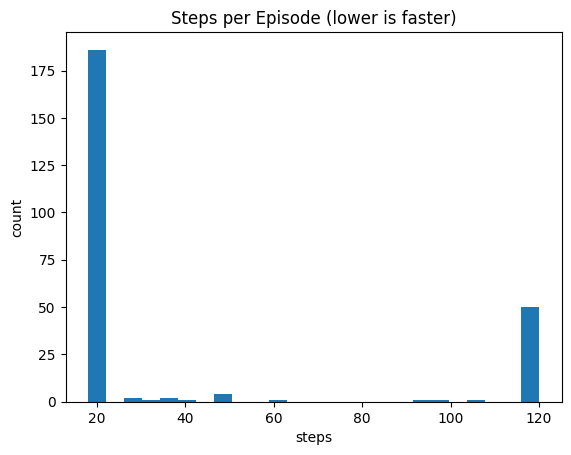

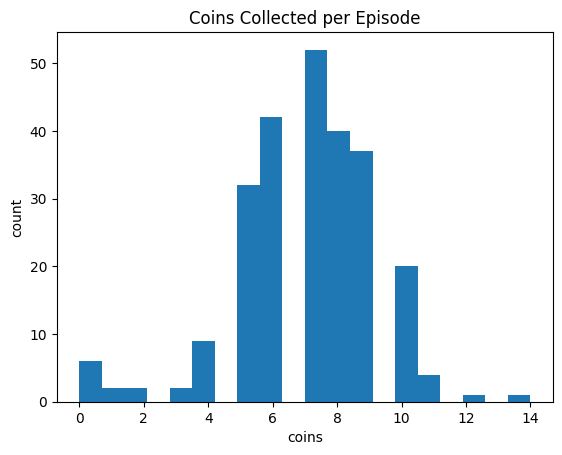

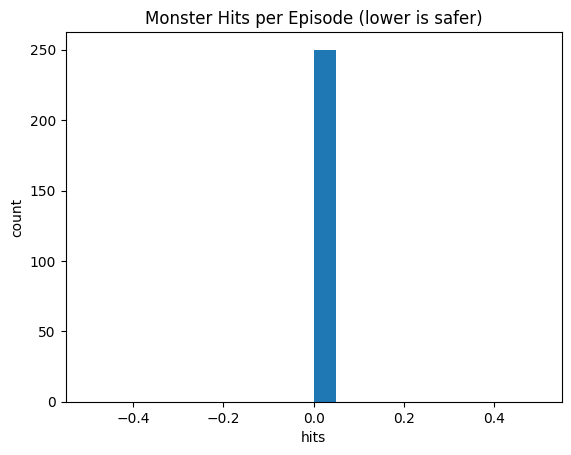

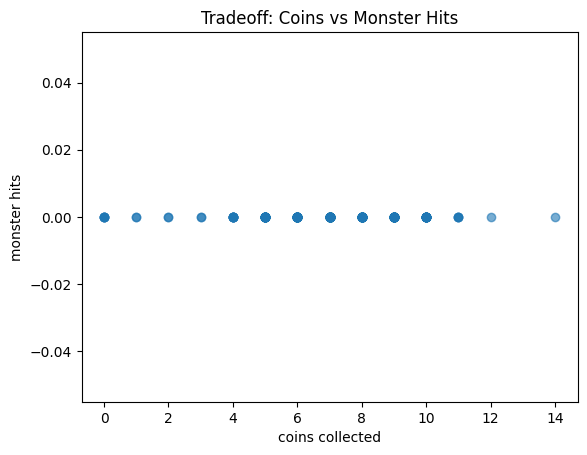

In [ ]:
# ============================
# 6.3 Dashboard-like plots (lightweight)
# ============================

plt.figure()
plt.hist(df["steps"], bins=25)
plt.title("Steps per Episode (lower is faster)")
plt.xlabel("steps")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(df["coins_collected"], bins=20)
plt.title("Coins Collected per Episode")
plt.xlabel("coins")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(df["monster_hits"], bins=20)
plt.title("Monster Hits per Episode (lower is safer)")
plt.xlabel("hits")
plt.ylabel("count")
plt.show()

plt.figure()
plt.scatter(df["coins_collected"], df["monster_hits"], alpha=0.6)
plt.title("Tradeoff: Coins vs Monster Hits")
plt.xlabel("coins collected")
plt.ylabel("monster hits")
plt.show()

### 🔎 Checkpoint 6 — Interpreting Dashboards
Looking at the tradeoff plot (coins vs hits), what does the shape tell you?

If you wanted “safer behavior,” what would you change:
- weights?
- environment?
- agent designs?

## 7. Coordinator Weight Sweeps (What-if Analysis)

We now treat weights like *policy knobs* and observe how system behavior changes.

This is an important “agentic systems engineering” skill:
- **don’t** guess which configuration is best
- **measure** the outcomes across scenarios

In [ ]:
# ============================
# 7.1 Weight sweep utility
# ============================

def sweep(goal_w_list, coin_w_list, safety_w_list, time_w=0.5, n_episodes=120):
    results = []
    for gw in goal_w_list:
        for cw in coin_w_list:
            for sw in safety_w_list:
                c = Coordinator(weights={"goal":gw,"coins":cw,"safety":sw,"time":time_w}, temperature=0.15)
                d = evaluate(c, n_episodes=n_episodes)
                results.append({
                    "goal_w": gw, "coin_w": cw, "safety_w": sw, "time_w": time_w,
                    "success_rate": d["success"].mean(),
                    "avg_steps": d["steps"].mean(),
                    "avg_coins": d["coins_collected"].mean(),
                    "avg_hits": d["monster_hits"].mean(),
                    "avg_scalar": d["scalar_return"].mean(),
                })
    return pd.DataFrame(results)

grid = sweep(goal_w_list=[2.0,3.0,4.0], coin_w_list=[0.5,1.0,2.0], safety_w_list=[1.0,2.0,3.0], n_episodes=100)
grid.sort_values(["success_rate","avg_hits","avg_steps"], ascending=[False,True,True]).head(10)

,goal_w,coin_w,safety_w,time_w,success_rate,avg_steps,avg_coins,avg_hits,avg_scalar
18,4.0,0.5,1.0,0.5,1.00,20.85,6.67,0.46,6.6665
24,4.0,2.0,1.0,0.5,0.98,20.49,7.91,0.34,19.1951
15,3.0,2.0,1.0,0.5,0.94,24.59,7.48,0.31,17.2241
21,4.0,1.0,1.0,0.5,0.91,27.23,7.35,0.34,10.3777
3,2.0,1.0,1.0,0.5,0.89,33.26,7.71,0.04,9.1174
6,2.0,2.0,1.0,0.5,0.89,38.26,9.23,0.18,19.6774
5,2.0,1.0,3.0,0.5,0.87,31.90,6.99,0.00,8.4110
9,3.0,0.5,1.0,0.5,0.87,35.73,6.99,0.27,5.4777
12,3.0,1.0,1.0,0.5,0.87,31.49,7.02,0.48,8.8351
2,2.0,0.5,3.0,0.5,0.86,32.90,6.27,0.00,4.5260


In [ ]:
# Heatmap-like view using a pivot table (no extra deps)
pivot = grid.pivot_table(index="coin_w", columns="safety_w", values="avg_hits", aggfunc="mean")
pivot.style.format("{:.2f}").set_caption("Avg monster hits (lower is better) across coin_w x safety_w")

safety_w,1.000000,2.000000,3.000000
coin_w,,,
0.500000,0.26,0.00,0.00
1.000000,0.29,0.01,0.00
2.000000,0.28,0.01,0.00


### 🔎 Checkpoint 7 — Governance Question
In a real system, who is allowed to change weights?

What controls would you require before weight updates go to production?

## 8. Adding Learning: Coordinator as a Simple Bandit Learner

So far, sub-agents are heuristic specialists and the coordinator is hand-tuned.

Now we add **learning** at the coordinator level:
- It tries different weight settings (arms)
- It learns which yields the best scalar utility under current conditions

This is **not full deep RL**. It is a lightweight, teachable stepping stone.

In [ ]:
# ============================
# 8.1 Bandit-style coordinator selection
# ============================
import math

WEIGHT_ARMS = [
    {"goal": 4.0, "coins": 0.8, "safety": 2.5, "time": 0.5},  # escape+safe
    {"goal": 3.0, "coins": 1.5, "safety": 2.0, "time": 0.5},  # balanced
    {"goal": 2.5, "coins": 2.2, "safety": 1.5, "time": 0.5},  # coin-hungry
    {"goal": 3.5, "coins": 1.0, "safety": 3.0, "time": 0.7},  # very cautious
]

def ucb1_select(counts, values, t, c=1.5):
    # counts[i] = pulls, values[i] = mean reward
    for i in range(len(counts)):
        if counts[i] == 0:
            return i
    ucb = [values[i] + c * math.sqrt(math.log(t+1) / counts[i]) for i in range(len(counts))]
    return int(np.argmax(ucb))

def bandit_train(n_rounds=60, eval_episodes=60):
    counts = [0]*len(WEIGHT_ARMS)
    values = [0.0]*len(WEIGHT_ARMS)
    history = []

    for t in range(n_rounds):
        arm = ucb1_select(counts, values, t)
        coord = Coordinator(weights=WEIGHT_ARMS[arm], temperature=0.15)
        d = evaluate(coord, n_episodes=eval_episodes)
        reward = d["scalar_return"].mean()

        counts[arm] += 1
        # incremental mean
        values[arm] += (reward - values[arm]) / counts[arm]

        history.append({"round":t, "arm":arm, "mean_scalar":reward, "success":d["success"].mean(),
                        "avg_hits":d["monster_hits"].mean(), "avg_coins":d["coins_collected"].mean()})
    return pd.DataFrame(history), counts, values

hist, counts, values = bandit_train(n_rounds=50, eval_episodes=50)
hist.tail()

,round,arm,mean_scalar,success,avg_hits,avg_coins
45,45,2,19.1668,0.90,0.04,7.86
46,46,2,18.7366,0.84,0.04,7.76
47,47,2,18.8684,0.90,0.06,7.74
48,48,2,18.5832,0.86,0.08,7.68
49,49,2,19.1952,0.88,0.04,7.90


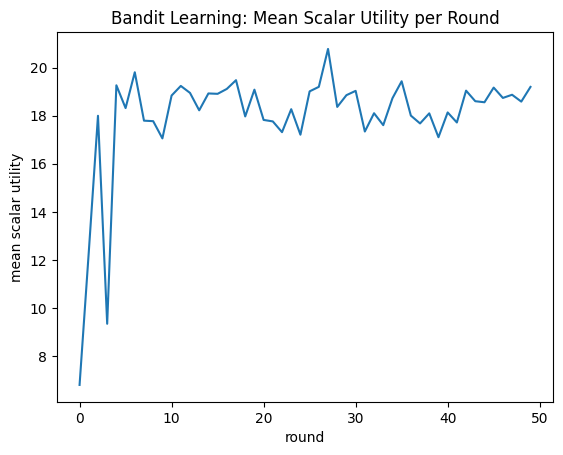

Best arm: 2 weights: {'goal': 2.5, 'coins': 2.2, 'safety': 1.5, 'time': 0.5}
Counts: [1, 1, 47, 1]


In [ ]:
plt.figure()
plt.plot(hist["round"], hist["mean_scalar"])
plt.title("Bandit Learning: Mean Scalar Utility per Round")
plt.xlabel("round")
plt.ylabel("mean scalar utility")
plt.show()

best_arm = int(np.argmax(values))
print("Best arm:", best_arm, "weights:", WEIGHT_ARMS[best_arm])
print("Counts:", counts)

### 🔎 Checkpoint 8 — Learning Pitfalls
What could go wrong if the environment changes over time (e.g., more monsters)?

How might you detect that your “best arm” is no longer best?

## 9. Optional Online API Calls (OPT-IN)

Sometimes you want an LLM (large language model) to help with:
- proposing new weight settings
- explaining tradeoffs
- generating a human-readable run report

This section is **optional** and is designed to work with a compatible API setup.

**Important:** Running online calls may cost money and may require credentials.

In [ ]:
# ============================
# 9.1 API Setup (OPT-IN)
# ============================
# This cell is intentionally defensive:
# - If you don't have API keys or the dependency, the notebook still runs.
#
# Replace this with the SAME API setup pattern used in your course environment.
# For example, you might have:
#   from openai import OpenAI
#   client = OpenAI()
#
# Or a proxy client provided by instructors.

USE_ONLINE_API = False  # set True only if your environment is configured

client = None
try:
    # Example placeholder (commented out by default):
    # from openai import OpenAI
    # client = OpenAI()
    pass
except Exception as e:
    print("API client not available:", e)

print("USE_ONLINE_API =", USE_ONLINE_API)

USE_ONLINE_API = False


In [ ]:
# ============================
# 9.2 Example: Ask an LLM for weight suggestions (OPT-IN)
# ============================
# This is a template. It will only run if USE_ONLINE_API=True AND client is configured.

def suggest_weights_via_llm(context_summary: str):
    if not USE_ONLINE_API or client is None:
        raise RuntimeError("Online API is disabled or client not configured.")

    prompt = f"""You are helping tune a multi-objective coordinator for a cave-escape RL system.
We have three objectives: escape success, coin collection, safety (avoid monsters), plus time pressure.
Given this evaluation summary:

{context_summary}

Propose 3 weight settings (goal, coins, safety, time) with brief reasoning.
Return JSON list of objects with keys: goal, coins, safety, time, rationale."""

    # Replace with your course's approved API call pattern:
    # resp = client.responses.create(
    #     model="gpt-4.1-mini",
    #     input=prompt
    # )
    # return resp.output_text
    raise NotImplementedError("Replace with your approved client call pattern.")

# Example context
context = summary.to_string(index=False)
print(context)

           metric    value
     success_rate  0.80000
        avg_steps 40.55600
        avg_coins  6.98800
 avg_monster_hits  0.00000
avg_scalar_return  8.98244


### 🔎 Checkpoint 9 — Responsible Use
When is it appropriate to use an online model to tune weights?
When should weight changes be based strictly on offline evaluation?

## 10. Wrap-Up: What You Should Know Now

You have:
- Modeled **explicit multi-agent objectives**
- Implemented a **coordinator** to arbitrate tradeoffs
- Evaluated behavior with **dashboard-style plots**
- Performed **what-if sweeps** over weights
- Added **learning** via a simple bandit approach
- Seen how to integrate **optional online APIs** responsibly

### Final Reflection
If this were a real cave rescue system:
- Which metrics would you show to an operations leader?
- Which metrics would you show to an engineer?
- What would trigger a “pause deployment” decision?